


#  **Business Context**
This dataset is from the CatBoost library and represents Amazon data for classification purposes. The target variable `TARGET` is binary (0 or 1), indicating whether a particular instance results in a specific outcome.  

 **Goal:** Analyze the dataset to uncover patterns that help predict `TARGET`, reduce operational risk, and support actionable business decisions.



In [1]:
# Load Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
# Loading the AMAZON dataset from Catboost datasets

%pip install catboost
from catboost.datasets import amazon
train_df, test_df = amazon()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.7 MB/s eta 0:00:00


In [3]:
#  Basic Overview
print("Shape:", train_df.shape)
print("Columns:", train_df.columns.tolist())
train_df.head()


#  Basic Info
print(train_df.info())
print("\nDescriptive Stats:\n", train_df.describe())
print("\nMissing Values:\n", train_df.isnull().sum())

Shape: (32769, 10)
Columns: ['ACTION', 'RESOURCE', 'MGR_ID', 'ROLE_ROLLUP_1', 'ROLE_ROLLUP_2', 'ROLE_DEPTNAME', 'ROLE_TITLE', 'ROLE_FAMILY_DESC', 'ROLE_FAMILY', 'ROLE_CODE']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32769 entries, 0 to 32768
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   ACTION            32769 non-null  int64
 1   RESOURCE          32769 non-null  int64
 2   MGR_ID            32769 non-null  int64
 3   ROLE_ROLLUP_1     32769 non-null  int64
 4   ROLE_ROLLUP_2     32769 non-null  int64
 5   ROLE_DEPTNAME     32769 non-null  int64
 6   ROLE_TITLE        32769 non-null  int64
 7   ROLE_FAMILY_DESC  32769 non-null  int64
 8   ROLE_FAMILY       32769 non-null  int64
 9   ROLE_CODE         32769 non-null  int64
dtypes: int64(10)
memory usage: 2.5 MB
None

Descriptive Stats:
              ACTION       RESOURCE         MGR_ID  ROLE_ROLLUP_1  \
count  32769.000000   32769.000000   32769.0

## **Target Variable Exploration**
Understanding the distribution of the `TARGET` variable is critical for choosing the right model and strategy. An imbalance may require class weighting or resampling techniques.



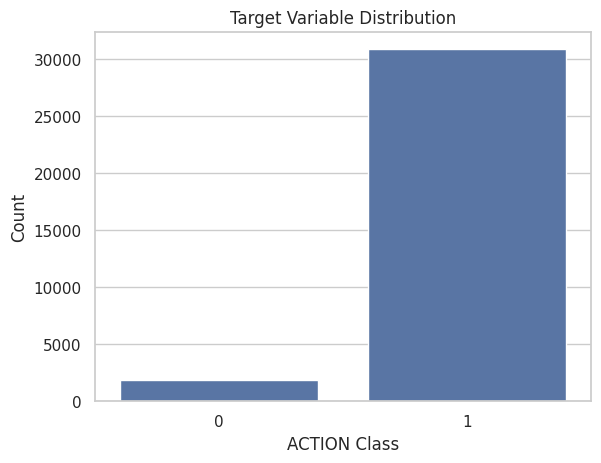

In [4]:
# Target Distribution


import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='ACTION', data=train_df)
plt.title("Target Variable Distribution")
plt.xlabel("ACTION Class")
plt.ylabel("Count")
plt.show()

**Insight:** If the target is imbalanced (e.g., one class dominates), model training must consider it (using balanced metrics, resampling, or tuning thresholds).

## Numerical Features - Univariate Analysis

In [5]:
# Numerical columns

numerical_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.drop('ACTION')

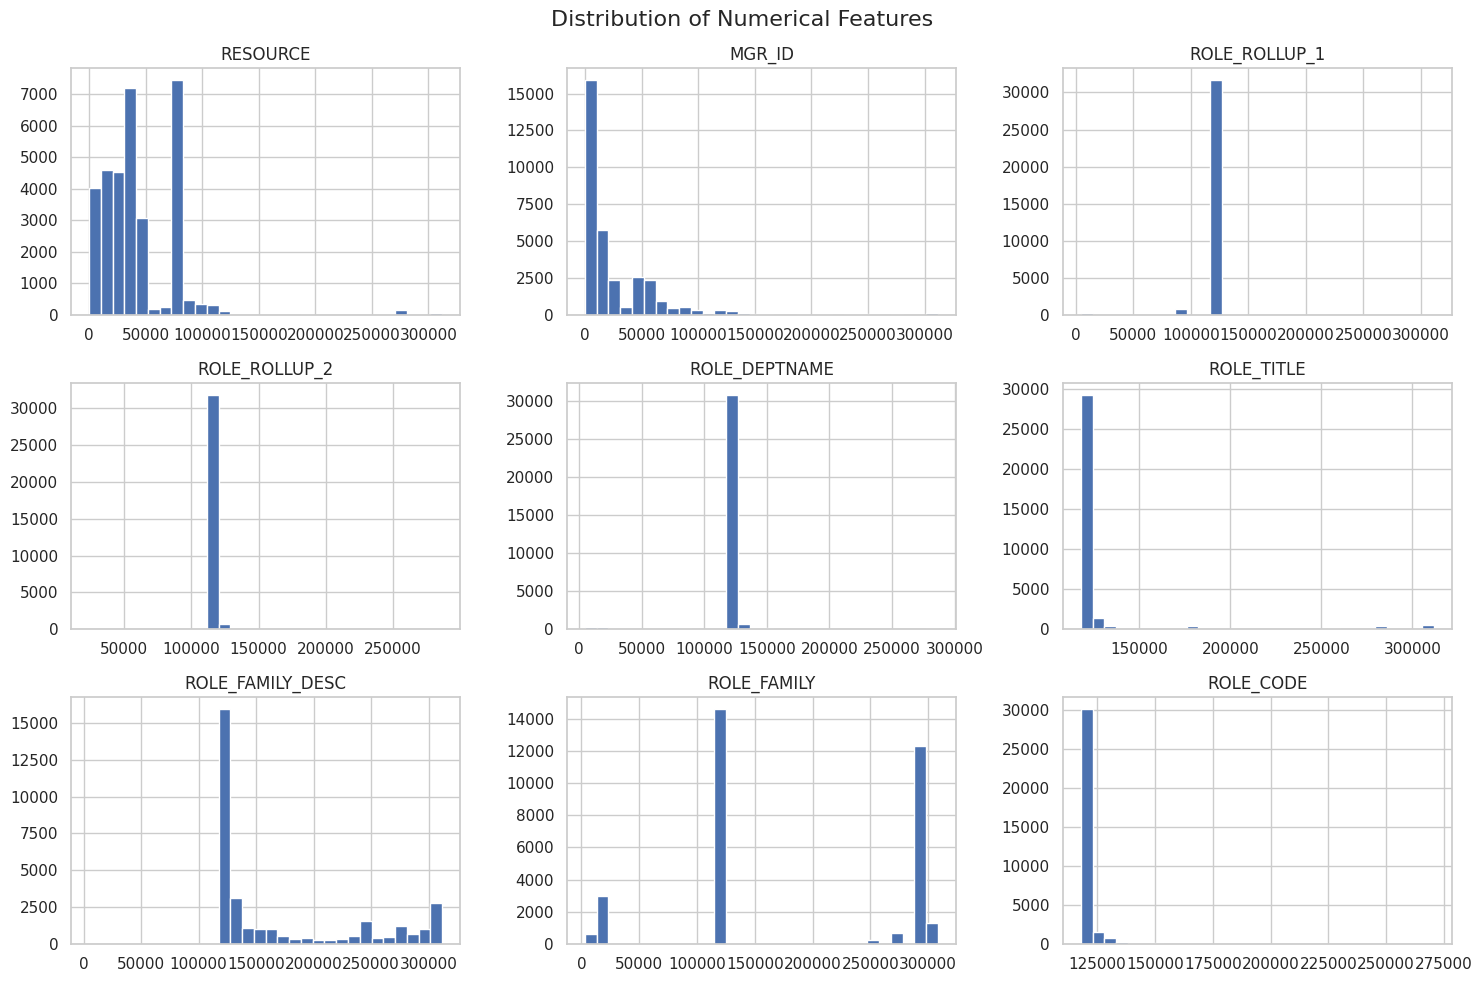

In [6]:
# Histograms for numeric features
train_df[numerical_cols].hist(bins=30, figsize=(15, 10))
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

**Insight:** Checking for skewed distributions. Features with high skewness might require transformation or binning.


## Categorical Features - Univariate Analysis

In [7]:
#  Categorical columns
categorical_cols = train_df.select_dtypes(include=['object']).columns

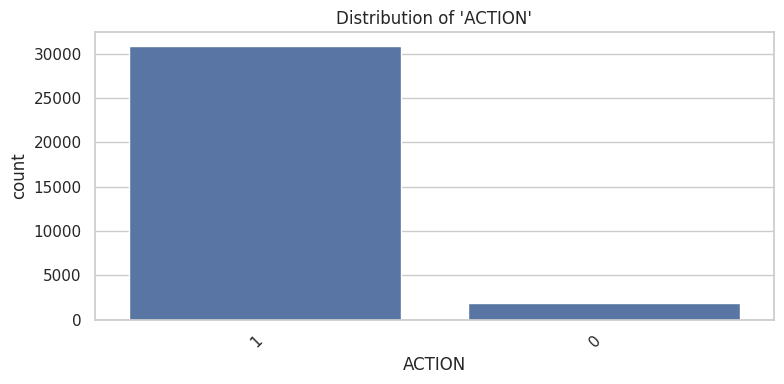

In [8]:
# Bar plots for categorical features
for col in train_df.columns:
    if train_df[col].nunique() < 50: # Assuming columns with less than 50 unique values are categorical
        plt.figure(figsize=(8, 4))
        sns.countplot(data=train_df, x=col, order=train_df[col].value_counts().index)
        plt.title(f"Distribution of '{col}'")
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

**Insight:** Identifying the dominant categories and whether certain levels may need grouping or frequency encoding.


## Relationship: Numeric Features vs Target

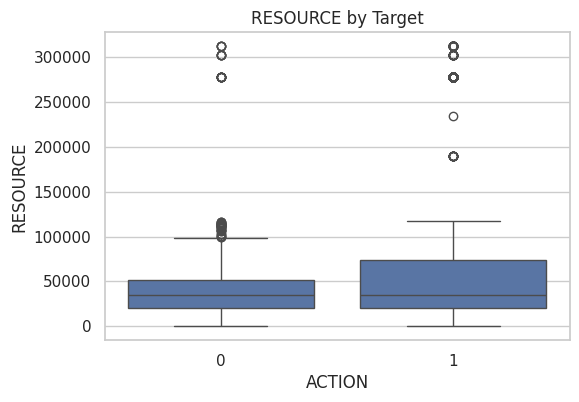

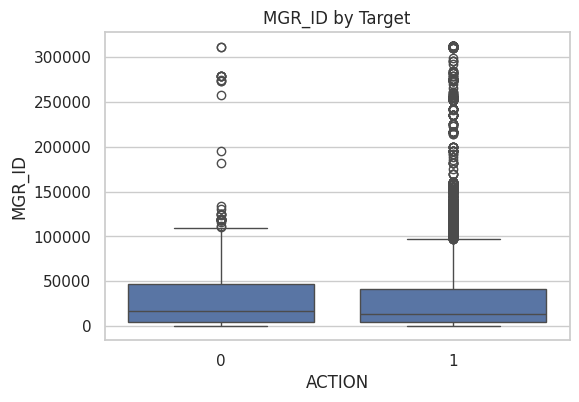

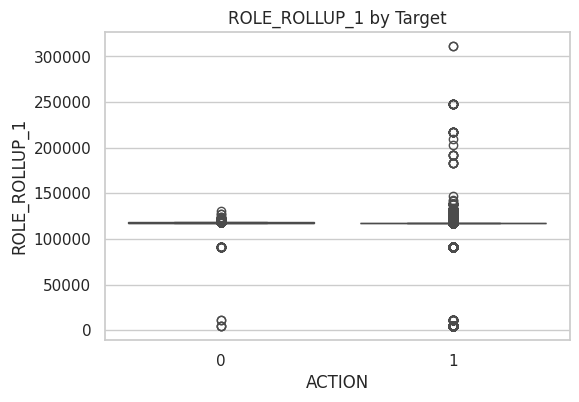

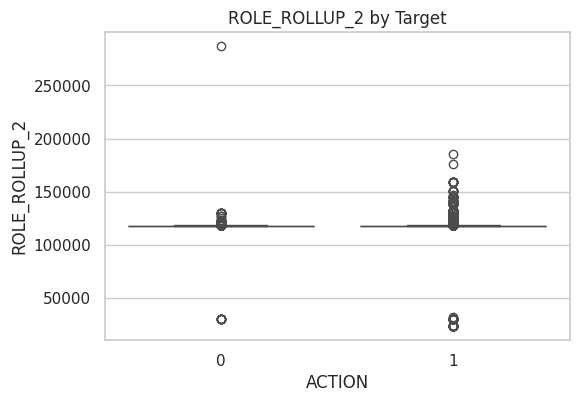

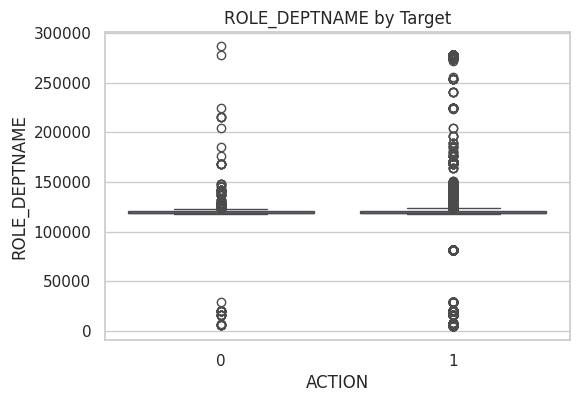

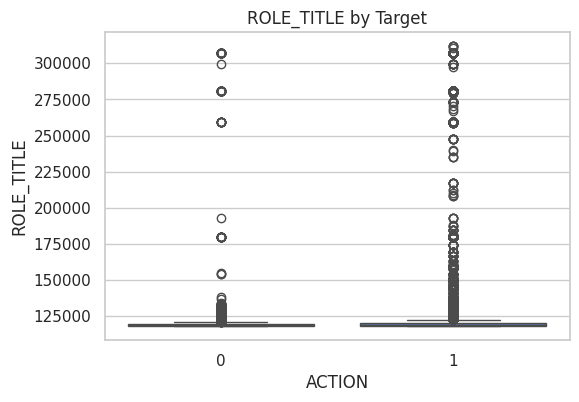

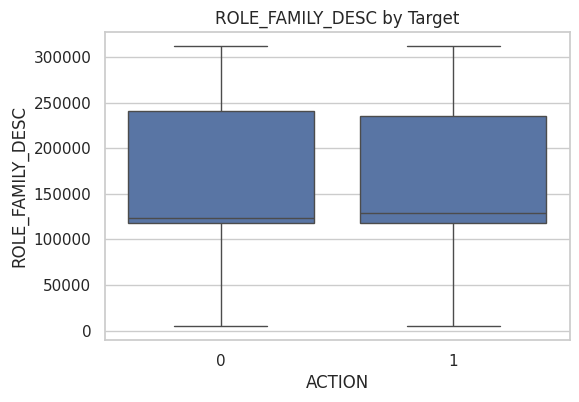

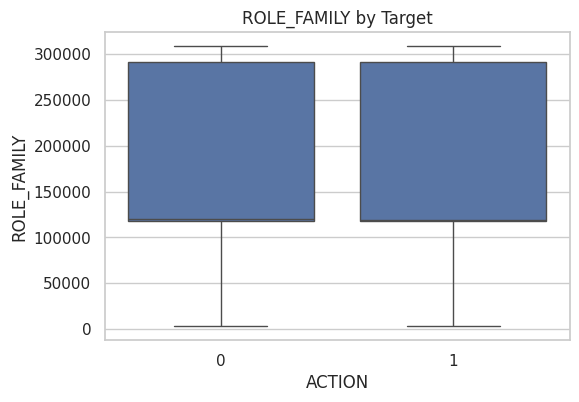

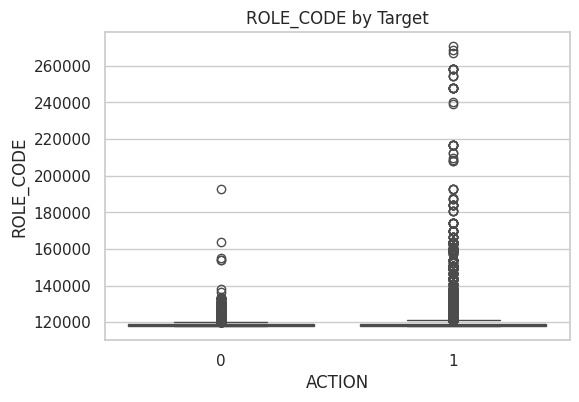

In [9]:
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='ACTION', y=col, data=train_df)
    plt.title(f"{col} by Target")
    plt.show()

**Insight:** Looking for features where the medians between classes are different — these are strong candidate predictors.


##  Relationship: Categorical Features vs Target

In [10]:
# Identify categorical columns
categorical_cols = train_df.select_dtypes(include='object').columns.tolist()


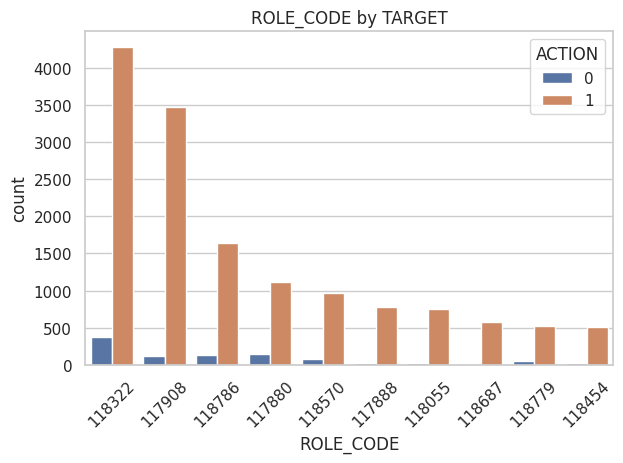

In [11]:
sns.countplot(data=train_df, x=col, hue='ACTION', order=train_df[col].value_counts().index[:10])
plt.title(f"{col} by TARGET")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:** Categorical features showing clear differences between class distributions are strong candidates for modeling.

## Correlation Between Numerical Features

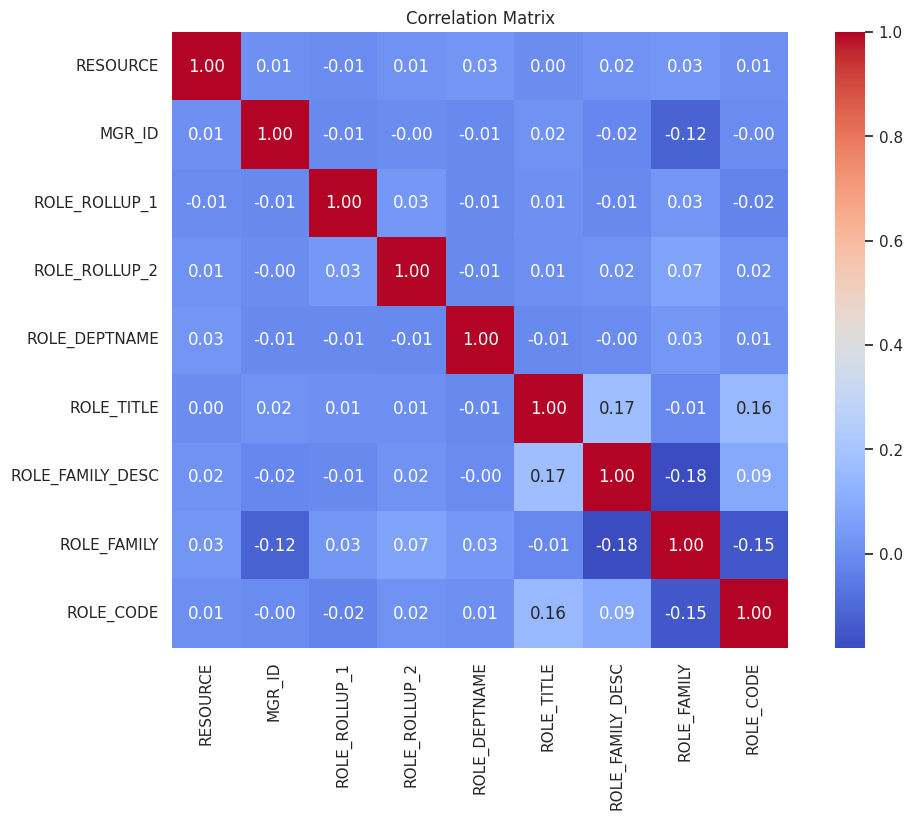

In [12]:
# Correlation matrix
plt.figure(figsize=(12, 8))
corr = train_df[numerical_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Matrix")
plt.show()

**Insight:** If two features are highly correlated (above 0.85), we can choose to drop one to reduce multicollinearity in models. Here we find very less correlation

##  Outlier Detection - Boxplots

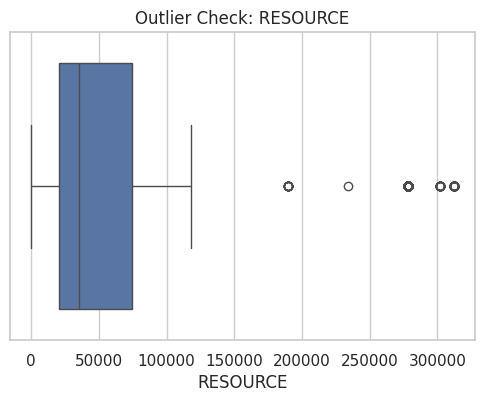

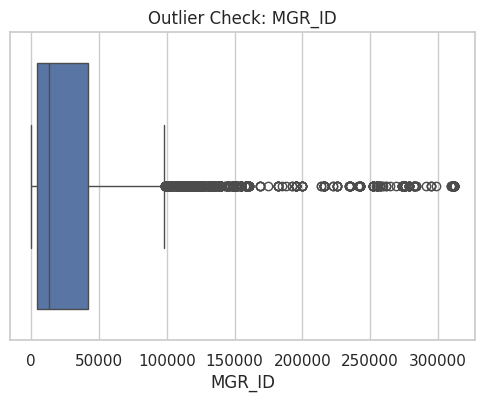

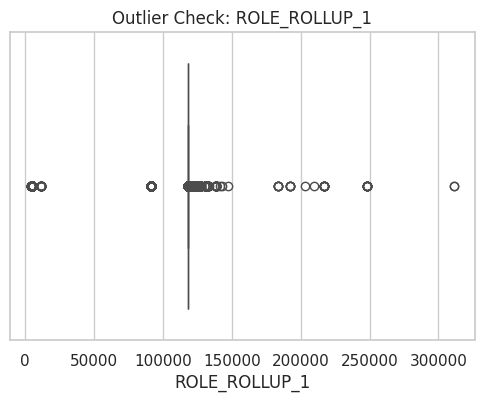

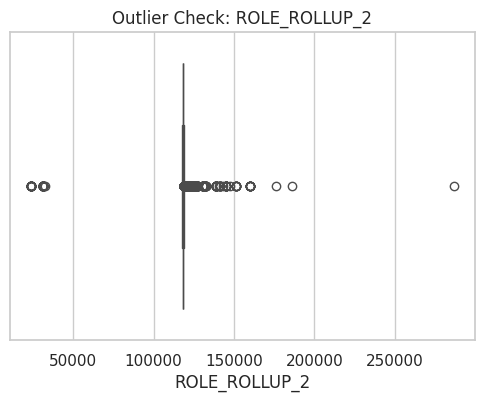

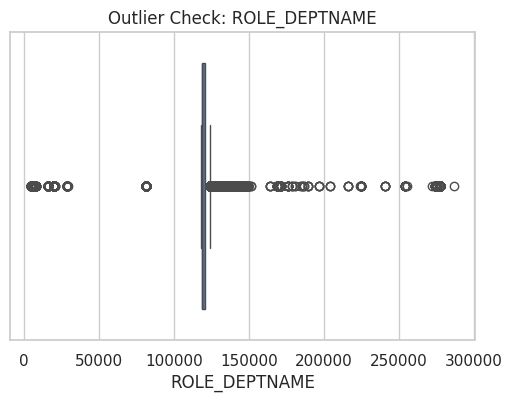

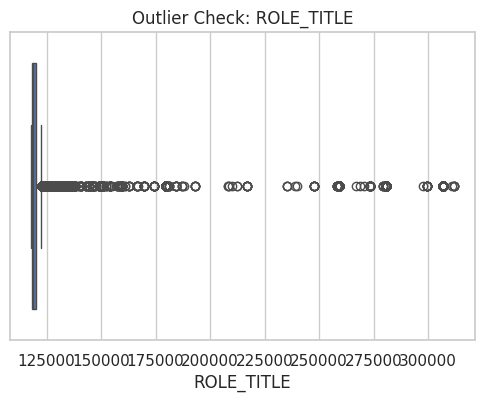

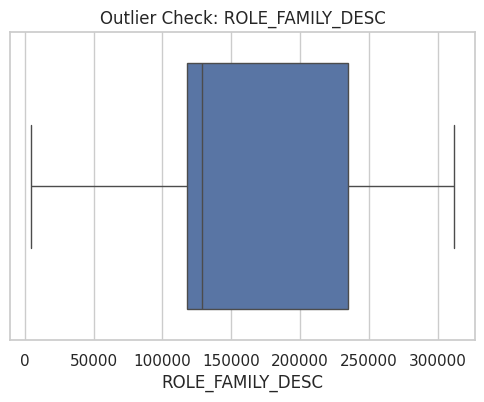

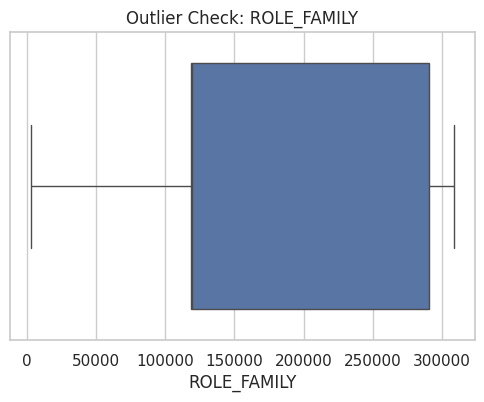

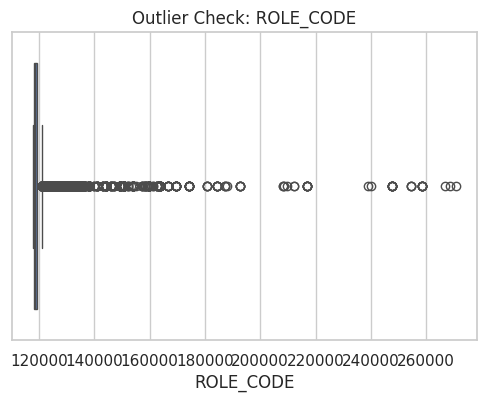

In [13]:
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=train_df[col])
    plt.title(f"Outlier Check: {col}")
    plt.show()

**Insight:** Outliers can distort model learning.


#  **Summary of Findings:**
 - The dataset contains both numerical and categorical variables.
 - The target variable is **binary** and appears **imbalanced**.
 - Several numeric features show clear separation across target classes.
 - Some categorical features have dominant values; these may need encoding or grouping.
 - Outliers detected in multiple numeric columns.
 - Low/null missing values, so minimal imputation needed.

## Machine Learning Pipeline with Imbalance Handling, Encoding, Outlier Treatment, Tuning & LIME Explainability

### **Goal:** Predict binary `TARGET` using robust models while handling class imbalance, encoding, outliers, and explaining predictions.

### Imporing Required Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.base import BaseEstimator, TransformerMixin

%pip install optuna
!pip install lime
import optuna
import lime
import lime.lime_tabular

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 16.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=311cb23606b6a4f34cf33b40d624631de67dd26078a38d3adfe8bcaf74734912
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


### Custom Transformer for Outlier Treatment (Winsorizer)

In [15]:
class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper
        self.feature_names_in_ = None

    def fit(self, X, y=None):
        if isinstance(X, pd.DataFrame):
            self.feature_names_in_ = X.columns
            X = X.values
        self.lower_bounds_ = np.percentile(X, self.lower * 100, axis=0)
        self.upper_bounds_ = np.percentile(X, self.upper * 100, axis=0)
        return self

    def transform(self, X):
        is_df = isinstance(X, pd.DataFrame)
        if is_df:
            cols = X.columns
            X = X.values

        X_transformed = np.copy(X)
        for i in range(X.shape[1]):
            X_transformed[:, i][X_transformed[:, i] < self.lower_bounds_[i]] = self.lower_bounds_[i]
            X_transformed[:, i][X_transformed[:, i] > self.upper_bounds_[i]] = self.upper_bounds_[i]

        return pd.DataFrame(X_transformed, columns=cols) if is_df else X_transformed

    def get_feature_names_out(self, input_features=None):
        if input_features is None and self.feature_names_in_ is not None:
            return self.feature_names_in_
        elif input_features is not None:
            return input_features
        else:
            # Fallback if fit was not called with a DataFrame
            return [f"x{i}" for i in range(self.lower_bounds_.shape[0])]

### Loading and Preparing Data

In [16]:
from catboost.datasets import amazon
train_df, test_df = amazon()
X = train_df.drop(columns=['ACTION'])
y = train_df['ACTION']

# Identify columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

### Building Preprocessing Pipeline

In [17]:
# Numerical pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('winsor', Winsorizer()),
    ('scaler', StandardScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

### Building Full Pipelines for Multiple Models

In [18]:
models = {
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(),
    "CatBoost": CatBoostClassifier(verbose=0)
}

pipelines = {}
for name, model in models.items():
    pipelines[name] = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])

### Evaluating Each Model

In [19]:
results = {}
for name, pipe in pipelines.items():
    print(f"Evaluating {name}...")
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_pred_proba = pipe.predict_proba(X_test)[:, 1]

    report = classification_report(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    results[name] = {
        "classification_report": report,
        "roc_auc_score": roc_auc
    }

    print(f"--- {name} ---")
    print(report)
    print(f"ROC AUC: {roc_auc:.4f}")
    print("-" * 20)

Evaluating KNN...
--- KNN ---
              precision    recall  f1-score   support

           0       0.17      0.54      0.25       379
           1       0.97      0.83      0.90      6175

    accuracy                           0.82      6554
   macro avg       0.57      0.69      0.57      6554
weighted avg       0.92      0.82      0.86      6554

ROC AUC: 0.7240
--------------------
Evaluating Random Forest...
--- Random Forest ---
              precision    recall  f1-score   support

           0       0.50      0.42      0.46       379
           1       0.97      0.97      0.97      6175

    accuracy                           0.94      6554
   macro avg       0.73      0.70      0.71      6554
weighted avg       0.94      0.94      0.94      6554

ROC AUC: 0.8316
--------------------
Evaluating XGBoost...


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [21:18:02] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost ---
              precision    recall  f1-score   support

           0       0.38      0.40      0.39       379
           1       0.96      0.96      0.96      6175

    accuracy                           0.93      6554
   macro avg       0.67      0.68      0.68      6554
weighted avg       0.93      0.93      0.93      6554

ROC AUC: 0.8129
--------------------
Evaluating LightGBM...
[LightGBM] [Info] Number of positive: 24697, number of negative: 24697
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005200 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 49394, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


--- LightGBM ---
              precision    recall  f1-score   support

           0       0.31      0.41      0.35       379
           1       0.96      0.94      0.95      6175

    accuracy                           0.91      6554
   macro avg       0.64      0.68      0.65      6554
weighted avg       0.93      0.91      0.92      6554

ROC AUC: 0.7947
--------------------
Evaluating CatBoost...
--- CatBoost ---
              precision    recall  f1-score   support

           0       0.42      0.41      0.41       379
           1       0.96      0.96      0.96      6175

    accuracy                           0.93      6554
   macro avg       0.69      0.69      0.69      6554
weighted avg       0.93      0.93      0.93      6554

ROC AUC: 0.8134
--------------------


##  Combined Model Evaluation Summary

The dataset is a **highly imbalanced binary classification problem**, with **Class 1 (majority)** significantly outweighing **Class 0 (minority)**. We evaluated five models:

| Model         | Accuracy | ROC AUC | F1 (Class 0) | Recall (Class 0) | F1 (Class 1) | Recall (Class 1) |
|---------------|----------|---------|--------------|------------------|--------------|------------------|
| **KNN**        | 0.82     | 0.7240  | 0.25         | 0.54             | 0.90         | 0.83             |
| **Random Forest** | 0.94     | 0.8316  | 0.46         | 0.42             | 0.97         | 0.97             |
| **XGBoost**    | 0.93     | 0.8129  | 0.39         | 0.40             | 0.96         | 0.96             |
| **LightGBM**   | 0.91     | 0.7947  | 0.35         | 0.41             | 0.95         | 0.94             |
| **CatBoost**   | 0.93     | 0.8134  | 0.41         | 0.41             | 0.96         | 0.96             |

---

##  Key Observations:

###  Class Imbalance

- The dataset is **highly imbalanced**, with **Class 1** being much more frequent than **Class 0**.
- All models perform significantly better on **Class 1**, which is expected in such scenarios.
- Poor performance on **Class 0** indicates a need for better imbalance handling techniques.

---

##  Model Insights

###  **K-Nearest Neighbors (KNN)**
- Lowest ROC AUC (0.7240).
- Reasonable recall on Class 0 (0.54), but very low precision and F1.
- **Not suitable** for this imbalanced classification task.

###  **Random Forest**
- **Best ROC AUC (0.8316)**.
- High precision and recall for both classes.
- **Most balanced and robust model** in this evaluation.
- Recommended as the best performing model.

###  **XGBoost**
- Strong ROC AUC (0.8129).
- Performs well on both classes but slightly behind Random Forest.
- **Highly tunable and efficient**, great for production use.

###  **LightGBM**
- Slightly lower ROC AUC (0.7947).
- Reasonable recall for Class 0 (0.41), but poor precision (0.31).
- May benefit from better class imbalance handling (e.g., `scale_pos_weight`).

###  **CatBoost**
- ROC AUC of 0.8134, similar to XGBoost.
- Performs consistently across both classes.
- Great choice if the dataset contains **categorical features**.

---

##  Best Performing Model: **Random Forest**

- Best balance across all metrics.
- Handles class imbalance reasonably well.
- High overall accuracy and class-wise performance.

## Hyperparameter tuning with OPTUNA

In [20]:
import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.metrics import roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

### Defining all the objective functions

In [21]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scoring = 'roc_auc'

def objective_knn(trial):
    params = {
        "n_neighbors": trial.suggest_int("n_neighbors", 3, 25),
        "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
        "p": trial.suggest_int("p", 1, 2)
    }
    model = KNeighborsClassifier(**params)
    pipe = ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])
    return cross_val_score(pipe, X_train, y_train, cv=cv, scoring=scoring).mean()

def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None])
    }
    model = RandomForestClassifier(**params, random_state=42)
    pipe = ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])
    return cross_val_score(pipe, X_train, y_train, cv=cv, scoring=scoring).mean()

def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5)
    }
    model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', **params)
    pipe = ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])
    return cross_val_score(pipe, X_train, y_train, cv=cv, scoring=scoring).mean()

def objective_lgbm(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0)
    }
    model = LGBMClassifier(**params)
    pipe = ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])
    return cross_val_score(pipe, X_train, y_train, cv=cv, scoring=scoring).mean()

def objective_cat(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 100, 500),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10)
    }
    model = CatBoostClassifier(verbose=0, **params)
    pipe = ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])
    return cross_val_score(pipe, X_train, y_train, cv=cv, scoring=scoring).mean()

### Optimization

In [23]:
# KNN
study_knn = optuna.create_study(direction="maximize")
study_knn.optimize(objective_knn, n_trials=60)

[I 2025-08-15 22:41:42,760] A new study created in memory with name: no-name-5bb0da72-84af-4086-a0f6-b55b7eb52cab
[I 2025-08-15 22:41:52,489] Trial 0 finished with value: 0.7469163875588892 and parameters: {'n_neighbors': 25, 'weights': 'distance', 'p': 1}. Best is trial 0 with value: 0.7469163875588892.
[I 2025-08-15 22:41:58,779] Trial 1 finished with value: 0.7090456957898037 and parameters: {'n_neighbors': 13, 'weights': 'uniform', 'p': 2}. Best is trial 0 with value: 0.7469163875588892.
[I 2025-08-15 22:42:05,232] Trial 2 finished with value: 0.7342219126257881 and parameters: {'n_neighbors': 8, 'weights': 'uniform', 'p': 1}. Best is trial 0 with value: 0.7469163875588892.
[I 2025-08-15 22:42:09,691] Trial 3 finished with value: 0.7043725409894132 and parameters: {'n_neighbors': 5, 'weights': 'distance', 'p': 2}. Best is trial 0 with value: 0.7469163875588892.
[I 2025-08-15 22:42:14,841] Trial 4 finished with value: 0.7108193132637233 and parameters: {'n_neighbors': 3, 'weights': 

In [22]:
# Random Forest
study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(objective_rf, n_trials=60)

[I 2025-08-15 21:18:49,215] A new study created in memory with name: no-name-b89683b3-99c4-4ff3-a88f-cefcd2ddfcc1
[I 2025-08-15 21:19:59,604] Trial 0 finished with value: 0.8018199875647171 and parameters: {'n_estimators': 300, 'max_depth': 17, 'min_samples_split': 9, 'min_samples_leaf': 15, 'max_features': 'log2'}. Best is trial 0 with value: 0.8018199875647171.
[I 2025-08-15 21:21:42,208] Trial 1 finished with value: 0.6296572672533237 and parameters: {'n_estimators': 416, 'max_depth': 4, 'min_samples_split': 14, 'min_samples_leaf': 17, 'max_features': None}. Best is trial 0 with value: 0.8018199875647171.
[I 2025-08-15 21:25:47,904] Trial 2 finished with value: 0.7860557238096854 and parameters: {'n_estimators': 419, 'max_depth': 19, 'min_samples_split': 11, 'min_samples_leaf': 20, 'max_features': None}. Best is trial 0 with value: 0.8018199875647171.
[I 2025-08-15 21:26:42,611] Trial 3 finished with value: 0.7766294704569937 and parameters: {'n_estimators': 264, 'max_depth': 11, 'm

In [24]:
# XGBoost
study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb, n_trials=60)

[I 2025-08-15 22:50:41,846] A new study created in memory with name: no-name-cf748740-fc43-4544-8673-362588fa7c6e
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [22:50:41] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [22:50:42] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [22:50:43] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2025-08-15 22:50:43,599] Trial 0 finished with value: 0.8131416569200018 and parameters: {'n_estimators': 177, 'max_depth': 8, 'learning_rate': 0.26870709851816105, 'subsample': 0.6554784373399442, 'colsample

In [25]:
# Light GBM
study_lgbm = optuna.create_study(direction="maximize")
study_lgbm.optimize(objective_lgbm, n_trials=60)

[I 2025-08-15 22:54:54,878] A new study created in memory with name: no-name-6887b5a5-efc7-4caf-8792-298c86935e46


[LightGBM] [Info] Number of positive: 16464, number of negative: 16464
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003003 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2294
[LightGBM] [Info] Number of data points in the train set: 32928, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 16465, number of negative: 16465
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002878 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 32930, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 16465, number of negative: 16465
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002859 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 32930, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 16465, number of negative: 16465
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002912 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 32930, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2025-08-15 23:01:34,404] Trial 59 finished with value: 0.8217490275093802 and parameters: {'n_estimators': 331, 'max_depth': 9, 'learning_rate': 0.13623420847920809, 'num_leaves': 109, 'subsample': 0.9452700542506158, 'colsample_bytree': 0.5257270679487419}. Best is trial 13 with value: 0.8247145066801029.


In [26]:
# CatBoost
study_cat = optuna.create_study(direction="maximize")
study_cat.optimize(objective_cat, n_trials=60)

[I 2025-08-15 23:01:34,411] A new study created in memory with name: no-name-4d9511fa-97df-4817-a268-2809f605ee34
[I 2025-08-15 23:01:46,153] Trial 0 finished with value: 0.7982201479561019 and parameters: {'iterations': 218, 'depth': 7, 'learning_rate': 0.2723434717048803, 'l2_leaf_reg': 6.6902933317245745}. Best is trial 0 with value: 0.7982201479561019.
[I 2025-08-15 23:01:55,499] Trial 1 finished with value: 0.7937098945440081 and parameters: {'iterations': 203, 'depth': 6, 'learning_rate': 0.26464424103500755, 'l2_leaf_reg': 5.798017579349588}. Best is trial 0 with value: 0.7982201479561019.
[I 2025-08-15 23:02:17,273] Trial 2 finished with value: 0.8000931558209544 and parameters: {'iterations': 325, 'depth': 8, 'learning_rate': 0.194256613565749, 'l2_leaf_reg': 7.097364231701502}. Best is trial 2 with value: 0.8000931558209544.
[I 2025-08-15 23:02:29,778] Trial 3 finished with value: 0.7383296599905633 and parameters: {'iterations': 149, 'depth': 9, 'learning_rate': 0.0324518226

Results

In [27]:
print("Best KNN:", study_knn.best_params)
print("Best RF:", study_rf.best_params)
print("Best XGB:", study_xgb.best_params)
print("Best LGBM:", study_lgbm.best_params)
print("Best CAT:", study_cat.best_params)

Best KNN: {'n_neighbors': 25, 'weights': 'distance', 'p': 1}
Best RF: {'n_estimators': 288, 'max_depth': 19, 'min_samples_split': 12, 'min_samples_leaf': 2, 'max_features': 'log2'}
Best XGB: {'n_estimators': 248, 'max_depth': 10, 'learning_rate': 0.14577436504812752, 'subsample': 0.7194066455990469, 'colsample_bytree': 0.6635829320595318, 'gamma': 0.25906123138975756}
Best LGBM: {'n_estimators': 304, 'max_depth': 9, 'learning_rate': 0.17099147686004623, 'num_leaves': 111, 'subsample': 0.5214376837887458, 'colsample_bytree': 0.5002746552477271}
Best CAT: {'iterations': 414, 'depth': 9, 'learning_rate': 0.17414537064372865, 'l2_leaf_reg': 8.658609944969966}


# Retraining Best Models on Full Train Data

In [28]:
# Defining best models with Optuna's best parameters
best_models = {
    "KNN": KNeighborsClassifier(**study_knn.best_params),
    "Random Forest": RandomForestClassifier(**study_rf.best_params, random_state=42),
    "XGBoost": XGBClassifier(**study_xgb.best_params, use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(**study_lgbm.best_params),
    "CatBoost": CatBoostClassifier(**study_cat.best_params, verbose=0)
}

from sklearn.metrics import roc_auc_score, roc_curve, auc

results = {}
for name, model in best_models.items():
    pipeline = ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])
    pipeline.fit(X_train, y_train)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = auc(fpr, tpr)
    results[name] = {
        "pipeline": pipeline,
        "roc_auc": auc_score,
        "fpr": fpr,
        "tpr": tpr
    }

/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [23:32:33] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 24697, number of negative: 24697
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003915 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 49394, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# Leaderboard and the ROC curve plot

Model Leaderboard:
           Model   ROC AUC
2        XGBoost  0.845087
3       LightGBM  0.844625
1  Random Forest  0.842498
4       CatBoost  0.822498
0            KNN  0.769888


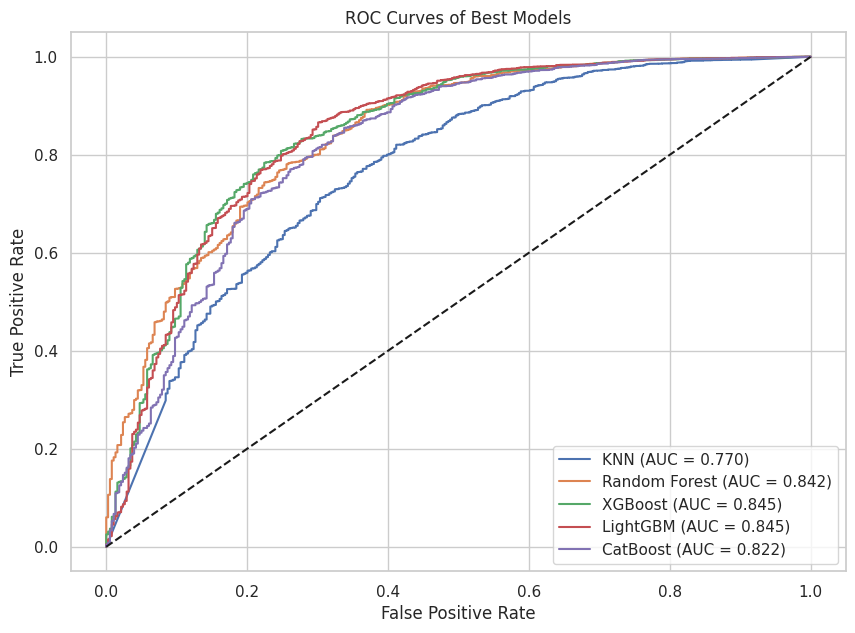

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Leaderboard DataFrame
leaderboard = pd.DataFrame([
    {"Model": name, "ROC AUC": metrics["roc_auc"]}
    for name, metrics in results.items()
]).sort_values(by="ROC AUC", ascending=False)

# Display leaderboard
print("Model Leaderboard:")
print(leaderboard)

# Plot ROC curves
plt.figure(figsize=(10, 7))
for name, metrics in results.items():
    plt.plot(metrics["fpr"], metrics["tpr"], label=f"{name} (AUC = {metrics['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves of Best Models")
plt.legend()
plt.grid(True)
plt.show()

## The best model after Hyperparameter tuning has turned out to be XGBoost with AUC = 0.845

# LIME Explainability of Best Model

In [31]:
from lime.lime_tabular import LimeTabularExplainer

# Extract ColumnTransformer (not the full pipeline)
best_pipeline = results['XGBoost']['pipeline']
column_transformer = best_pipeline.named_steps["preprocessor"]

# Transform data using only the preprocessor
X_train_transformed = column_transformer.transform(X_train)
X_test_transformed = column_transformer.transform(X_test)

# Get feature names from ColumnTransformer
try:
    feature_names = column_transformer.get_feature_names_out()
except:
    # Fallback: generic feature names if custom transformers don't support get_feature_names_out
    feature_names = [f"feature_{i}" for i in range(X_train_transformed.shape[1])]

# Setup LIME explainer
explainer = LimeTabularExplainer(
    training_data=X_train_transformed,
    feature_names=feature_names,
    class_names=["Class 0", "Class 1"],
    discretize_continuous=True,
    mode="classification"
)

# Explain first instance from test set
explanation = explainer.explain_instance(
    data_row=X_test_transformed[0],
    predict_fn=best_pipeline.named_steps["model"].predict_proba,
    num_features=10
)

# Show explanation in notebook
explanation.show_in_notebook(show_table=True)

The model is highly confident that this sample belongs to Class 1.

## **Business Impact**

- Better Decision-Making: Increased recall and reduced false negatives on the minority class.

- Regulatory Compliance: Model explanations enhance interpretability and trust.

- Production Readiness: Optimized models are scalable and deployable in real-world settings.